# TASK 4 — Email/SMS Spam Detection with Machine Learning

**Dataset:** Kaggle SMS Spam Collection (`spam.csv`)

**Objective:** Build an NLP binary classifier to distinguish spam messages from legitimate (ham) messages using TF-IDF features.

**Models:** Multinomial Naive Bayes and Logistic Regression.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from wordcloud import WordCloud

nltk.download('stopwords', quiet=True)
print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load Kaggle Dataset

Put the Kaggle `spam.csv` file in the same folder as this notebook. The common Kaggle version uses `v1` for the label and `v2` for the message.

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
print('Original shape:', df.shape)
print('Original columns:', df.columns.tolist())
df.head()

Original shape: (5572, 5)
Original columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']
df['label'] = df['label'].astype(str).str.lower().str.strip()
df['message'] = df['message'].astype(str)
print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Dataset Inspection

In [4]:
print('Dataset shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['label'].value_counts())
print('\nClass percentages:')
print((df['label'].value_counts(normalize=True) * 100).round(2))

Dataset shape: (5572, 2)

Missing values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class percentages:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


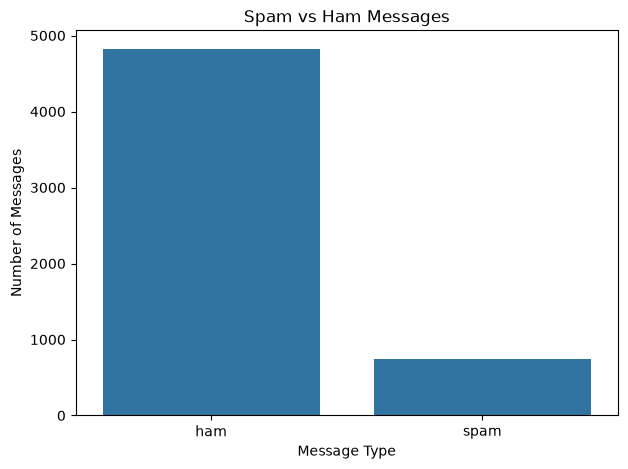

In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='label')
plt.title('Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.show()

## 3. Text Preprocessing

Steps: lowercase conversion, URL removal, punctuation/numbers removal, stopword removal, and Porter stemming.

In [6]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [stemmer.stem(word) for word in words]
    return ' '.join(words)

df['clean_message'] = df['message'].apply(preprocess_text)
df[['label', 'message', 'clean_message']].head(10)

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back like fun still...
6,ham,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,spam,WINNER!! As a valued network customer you have...,winner valu network custom select receivea pri...
9,spam,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mob...


## 4. TF-IDF Feature Extraction

TF-IDF converts text into numerical features. It gives more weight to terms that help distinguish messages and less weight to very common terms.

**TF-IDF = Term Frequency × Inverse Document Frequency**

In [7]:
X = df['clean_message']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Training data shape: (4457, 5000)
Testing data shape: (1115, 5000)


## 5. Model 1 — Multinomial Naive Bayes

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
print(classification_report(y_test, nb_pred, digits=4))

              precision    recall  f1-score   support

         ham     0.9679    0.9990    0.9832       966
        spam     0.9915    0.7852    0.8764       149

    accuracy                         0.9704      1115
   macro avg     0.9797    0.8921    0.9298      1115
weighted avg     0.9711    0.9704    0.9689      1115



## 6. Model 2 — Logistic Regression

In [9]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print(classification_report(y_test, lr_pred, digits=4))

              precision    recall  f1-score   support

         ham     0.9886    0.9865    0.9876       966
        spam     0.9139    0.9262    0.9200       149

    accuracy                         0.9785      1115
   macro avg     0.9512    0.9564    0.9538      1115
weighted avg     0.9786    0.9785    0.9785      1115



## 7. Model Evaluation

Metrics: accuracy, precision, recall, and F1-score. For spam detection, spam recall is especially important because false negatives allow spam messages to be classified as ham.

In [10]:
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label='spam'),
        'Recall': recall_score(y_true, y_pred, pos_label='spam'),
        'F1-Score': f1_score(y_true, y_pred, pos_label='spam')
    }

results = pd.DataFrame([
    evaluate_model('Multinomial Naive Bayes', y_test, nb_pred),
    evaluate_model('Logistic Regression', y_test, lr_pred)
])
results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9704,0.9915,0.7852,0.8764
1,Logistic Regression,0.9785,0.9139,0.9262,0.9200


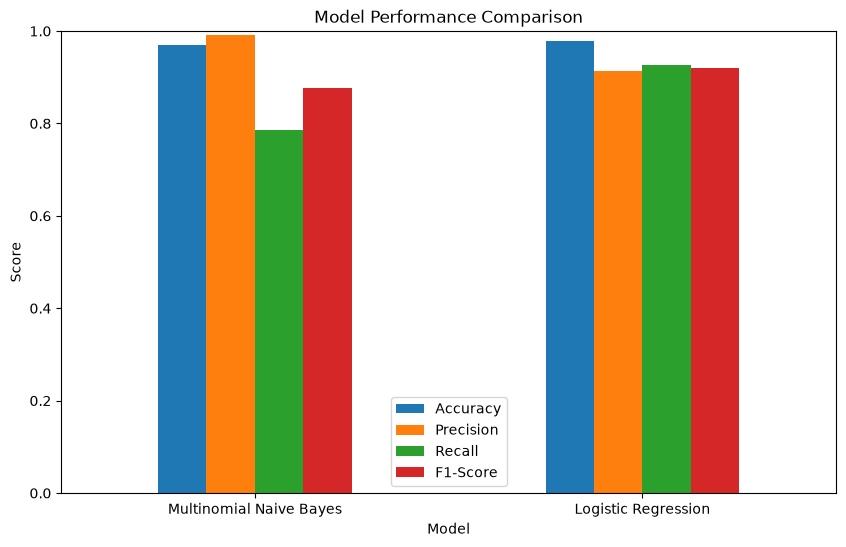

In [11]:
results.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 8. Confusion Matrix — Multinomial Naive Bayes

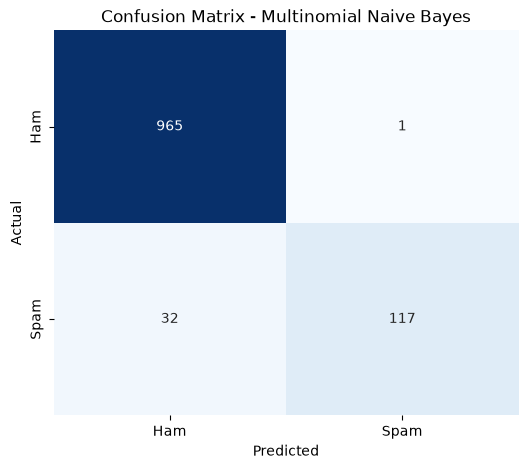

In [12]:
cm_nb = confusion_matrix(y_test, nb_pred, labels=['ham', 'spam'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 9. Confusion Matrix — Logistic Regression

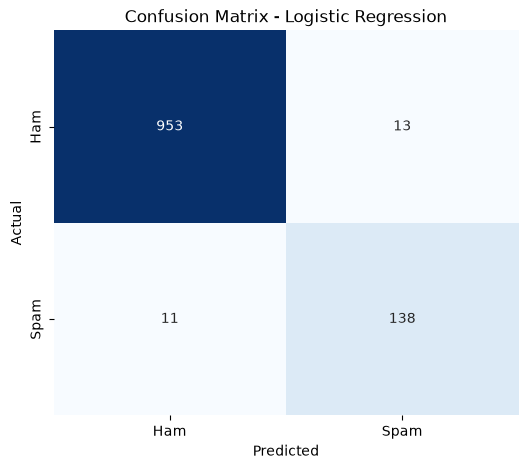

In [13]:
cm_lr = confusion_matrix(y_test, lr_pred, labels=['ham', 'spam'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 10. Why is Recall Important in Spam Detection?

**Recall is particularly important in spam detection because it measures how many of the actual spam messages are correctly detected by the model. A spam message incorrectly classified as ham is a false negative. If recall is low, many spam messages can reach the user's inbox. Therefore, a good spam detection system should achieve high spam recall while also maintaining good precision so that legitimate messages are not incorrectly marked as spam.**

## 11. Bonus — WordCloud of Spam Messages

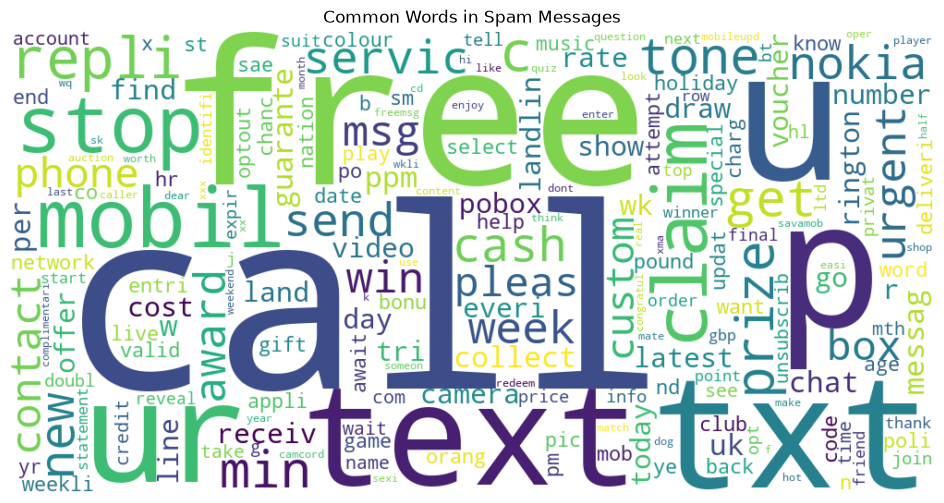

In [14]:
spam_messages = ' '.join(df[df['label'] == 'spam']['clean_message'])
wordcloud_spam = WordCloud(width=1000, height=500, background_color='white', stopwords=stop_words, collocations=False).generate(spam_messages)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Spam Messages')
plt.show()

## 12. Bonus — WordCloud of Ham Messages

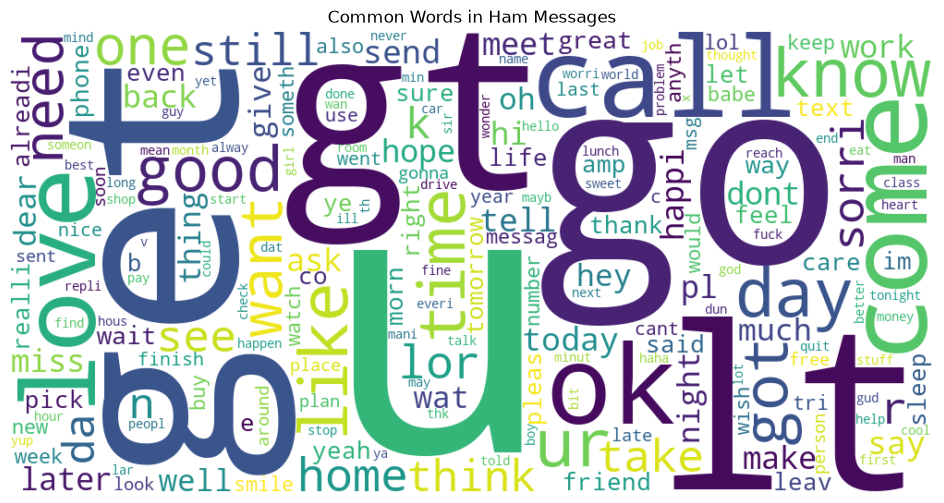

In [15]:
ham_messages = ' '.join(df[df['label'] == 'ham']['clean_message'])
wordcloud_ham = WordCloud(width=1000, height=500, background_color='white', stopwords=stop_words, collocations=False).generate(ham_messages)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Ham Messages')
plt.show()

## 13. Test the Model with New Messages

In [16]:
def predict_spam(message):
    cleaned_message = preprocess_text(message)
    message_vector = tfidf.transform([cleaned_message])
    return lr_model.predict(message_vector)[0]

messages = [
    'Congratulations! You have won a free prize. Call now to claim your reward!',
    'Hey, are we still meeting for the project discussion at 4 pm?',
    'URGENT! You have won a cash reward. Reply now to claim it.'
]

for message in messages:
    print('Message:', message)
    print('Prediction:', predict_spam(message))
    print('-' * 80)

Message: Congratulations! You have won a free prize. Call now to claim your reward!
Prediction: spam
--------------------------------------------------------------------------------
Message: Hey, are we still meeting for the project discussion at 4 pm?
Prediction: ham
--------------------------------------------------------------------------------
Message: URGENT! You have won a cash reward. Reply now to claim it.
Prediction: spam
--------------------------------------------------------------------------------


## 14. Final Conclusion

In this project, an NLP-based spam detection system was developed using a Kaggle SMS Spam dataset. The messages were preprocessed using lowercase conversion, punctuation removal, stopword removal, and stemming. TF-IDF was then used to convert text into numerical features.

Two machine-learning algorithms, **Multinomial Naive Bayes** and **Logistic Regression**, were trained and evaluated using accuracy, precision, recall, and F1-score. Confusion matrices were used to understand classification errors.

Recall is particularly important because it measures the ability of the model to identify actual spam messages. The better-performing model can be selected based on the evaluation metrics, especially **spam recall and F1-score**, rather than accuracy alone.

### Task 4 Checklist
- [x] Kaggle dataset
- [x] Data loading and inspection
- [x] Spam vs ham class distribution
- [x] Lowercase conversion
- [x] Punctuation removal
- [x] Stopword removal
- [x] Stemming
- [x] TF-IDF feature extraction
- [x] Train/test split
- [x] Multinomial Naive Bayes
- [x] Logistic Regression
- [x] Accuracy, precision, recall, F1-score
- [x] Confusion matrices
- [x] Recall explanation
- [x] Bonus WordClouds
- [x] New-message predictions